# Parte 1 - Análise inicial sem utilização de Técnicas de Feature Engineering

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# URL do arquivo
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Especificando a codificação para ler o arquivo CSV
dados_credito = pd.read_csv(url, encoding='ISO-8859-1', sep='\t', low_memory=False)
# or 'ISO-8859-1' if 'latin-1' doesn't work
nomes_cols = ['ID_CLIENTE','TIPO_FUNCIONARIO','DIA_PAGAMENTO','TIPO_ENVIO_APLICACAO','QUANT_CARTOES_ADICIONAIS','TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','QUANT_DEPENDENTES',
'NIVEL_EDUCACIONAL','ESTADO_NASCIMENTO','CIDADE_NASCIMENTO','NACIONALIDADE','ESTADO_RESIDENCIAL','CIDADE_RESIDENCIAL','BAIRRO_RESIDENCIAL','FLAG_TELEFONE_RESIDENCIAL',
'CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA','MESES_RESIDENCIA','FLAG_TELEFONE_MOVEL','FLAG_EMAIL','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS',
'FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS','FLAG_AMERICAN_EXPRESS','FLAG_OUTROS_CARTOES','QUANT_CONTAS_BANCARIAS','QUANT_CONTAS_BANCARIAS_ESPECIAIS',
'VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA','ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL','FLAG_TELEFONE_PROFISSIONAL',
'CODIGO_AREA_TELEFONE_PROFISSIONAL','MESES_NO_TRABALHO','CODIGO_PROFISSAO','TIPO_OCUPACAO','CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE',
'FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG','FLAG_CPF','FLAG_COMPROVANTE_RENDA','PRODUTO','FLAG_REGISTRO_ACSP','IDADE','CEP_RESIDENCIAL','CEP_PROFISSIONAL','ROTULO_ALVO_MAU']

dados_credito.columns = nomes_cols

dados_credito.describe()

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,TIPO_OCUPACAO,CODIGO_PROFISSAO_CONJUGE,NIVEL_EDUCACIONAL_CONJUGE,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU
count,49999.000000,49999.000000,49999.0,49999.000000,49999.000000,49999.000000,49999.0,49999.000000,48650.000000,46222.000000,...,42686.000000,21116.000000,17662.000000,49999.0,49999.0,49999.0,49999.0,49999.000000,49999.000000,49999.000000
mean,25001.000000,12.870077,0.0,1.006540,2.148323,0.650513,0.0,0.961599,1.252230,9.727035,...,2.484281,3.797926,0.296003,0.0,0.0,0.0,0.0,1.275706,43.248745,0.260805
std,14433.612391,6.608357,0.0,0.080607,1.322751,1.193666,0.0,0.202107,0.867841,10.668928,...,1.532262,5.212168,0.955688,0.0,0.0,0.0,0.0,0.988295,14.989115,0.439078
min,2.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,6.000000,0.000000
25%,12501.500000,10.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,31.000000,0.000000
50%,25001.000000,10.000000,0.0,1.000000,2.000000,0.000000,0.0,1.000000,1.000000,6.000000,...,2.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,41.000000,0.000000
75%,37500.500000,15.000000,0.0,1.000000,2.000000,1.000000,0.0,1.000000,1.000000,15.000000,...,4.000000,11.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,53.000000,1.000000
max,50000.000000,25.000000,0.0,2.000000,7.000000,53.000000,0.0,2.000000,5.000000,228.000000,...,5.000000,17.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.000000,1.000000


In [2]:
dados_credito.isnull().sum().sort_values(ascending=True)



# Removendo linhas com valores nulos
dados_credito_limpo = dados_credito.dropna()

# Exibindo a quantidade de valores nulos após a remoção
print(dados_credito_limpo.isnull().sum().sort_values(ascending=True))

dados_credito_limpo.head()

ID_CLIENTE                           0
QUANT_CONTAS_BANCARIAS               0
QUANT_CONTAS_BANCARIAS_ESPECIAIS     0
VALOR_PATRIMONIO_PESSOAL             0
QUANT_CARROS                         0
EMPRESA                              0
ESTADO_PROFISSIONAL                  0
CIDADE_PROFISSIONAL                  0
BAIRRO_PROFISSIONAL                  0
FLAG_TELEFONE_PROFISSIONAL           0
CODIGO_AREA_TELEFONE_PROFISSIONAL    0
MESES_NO_TRABALHO                    0
CODIGO_PROFISSAO                     0
TIPO_OCUPACAO                        0
CODIGO_PROFISSAO_CONJUGE             0
NIVEL_EDUCACIONAL_CONJUGE            0
FLAG_DOCUMENTO_RESIDENCIAL           0
FLAG_RG                              0
FLAG_CPF                             0
FLAG_COMPROVANTE_RENDA               0
PRODUTO                              0
FLAG_REGISTRO_ACSP                   0
IDADE                                0
CEP_RESIDENCIAL                      0
FLAG_OUTROS_CARTOES                  0
FLAG_AMERICAN_EXPRESS    

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
8,10,C,5,0,0,1,F,1,0,0,...,0,0,0,0,1,N,41,914,914,0
12,14,C,25,0,0,1,F,2,2,0,...,0,0,0,0,1,N,36,713,713,0
16,18,C,10,0,0,1,F,1,0,0,...,0,0,0,0,1,N,32,267,267,0
23,25,C,10,0,0,1,F,5,0,0,...,0,0,0,0,1,N,47,580,580,0


In [3]:
valores_unicos_sexo = dados_credito_limpo['SEXO'].unique()
valores_unicos_sexo


dados_credito_limpo.loc[dados_credito_limpo["SEXO"].replace(' ', np.nan).isna(), "SEXO"] = 'N'
dados_credito_limpo.head()

,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
8,10,C,5,0,0,1,F,1,0,0,...,0,0,0,0,1,N,41,914,914,0
12,14,C,25,0,0,1,F,2,2,0,...,0,0,0,0,1,N,36,713,713,0
16,18,C,10,0,0,1,F,1,0,0,...,0,0,0,0,1,N,32,267,267,0
23,25,C,10,0,0,1,F,5,0,0,...,0,0,0,0,1,N,47,580,580,0


In [4]:
# Verificando valores disponíveis pra sexo
dados_credito_limpo['SEXO'].unique()


mapping = {'M': 0, 'F': 1, 'N': 2}
dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)

dados_credito_limpo['SEXO'].unique()

/var/folders/xz/khfgvmxj4tsd1nl_m4gdk7780000gn/T/ipykernel_29459/691337772.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)


array([0, 1, 2])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


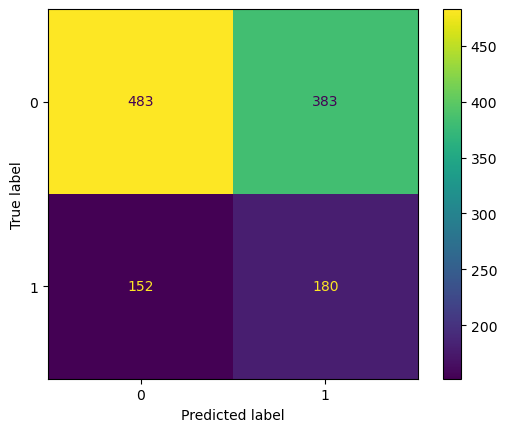

In [5]:
y = dados_credito_limpo["ROTULO_ALVO_MAU"]

# Drop the specified columns
columns_to_drop = ['TIPO_FUNCIONARIO', 'TIPO_ENVIO_APLICACAO', 'ESTADO_NASCIMENTO', 'CIDADE_NASCIMENTO',
                  'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL', 'FLAG_TELEFONE_RESIDENCIAL',
                  'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'FLAG_TELEFONE_MOVEL', 'EMPRESA', 'ESTADO_PROFISSIONAL',
                  'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
                  'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'FLAG_REGISTRO_ACSP', 'CEP_RESIDENCIAL', 'CEP_PROFISSIONAL']
X = dados_credito_limpo.drop(columns=columns_to_drop + ["ROTULO_ALVO_MAU"])


#
## train test split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=50)

model_filter = LogisticRegression(max_iter=1000, class_weight='balanced')
model_filter.fit(X_train,y_train)

y_pred=model_filter.predict(X_test)

metric_filter=confusion_matrix(y_test,y_pred)

cm = confusion_matrix( y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()


In [6]:
print(classification_report(y_test, y_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.76      0.56      0.64       866
           1       0.32      0.54      0.40       332

    accuracy                           0.55      1198
   macro avg       0.54      0.55      0.52      1198
weighted avg       0.64      0.55      0.58      1198



In [7]:
report_1 = classification_report(y_test, y_pred, output_dict=True)

report_1

{'0': {'precision': 0.7606299212598425,
  'recall': 0.5577367205542725,
  'f1-score': 0.6435709526982012,
  'support': 866.0},
 '1': {'precision': 0.3197158081705151,
  'recall': 0.5421686746987951,
  'f1-score': 0.4022346368715084,
  'support': 332.0},
 'accuracy': 0.5534223706176962,
 'macro avg': {'precision': 0.5401728647151788,
  'recall': 0.5499526976265339,
  'f1-score': 0.5229027947848548,
  'support': 1198.0},
 'weighted avg': {'precision': 0.6384400334921825,
  'recall': 0.5534223706176962,
  'f1-score': 0.5766897700150109,
  'support': 1198.0}}

# Parte 2 - Utilização das técnicas aprendidas durante o curso


### Carregamento dos dados para garantir que não há sujeira e importação de bibliotecas


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# URL do arquivo
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Carregando os dados
dados_credito = pd.read_csv(url, encoding='ISO-8859-1', sep='\t', low_memory=False)

# Nomes das colunas
nomes_cols = ['ID_CLIENTE','TIPO_FUNCIONARIO','DIA_PAGAMENTO','TIPO_ENVIO_APLICACAO','QUANT_CARTOES_ADICIONAIS',
              'TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','QUANT_DEPENDENTES','NIVEL_EDUCACIONAL',
              'ESTADO_NASCIMENTO','CIDADE_NASCIMENTO','NACIONALIDADE','ESTADO_RESIDENCIAL',
              'CIDADE_RESIDENCIAL','BAIRRO_RESIDENCIAL','FLAG_TELEFONE_RESIDENCIAL',
              'CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA','MESES_RESIDENCIA','FLAG_TELEFONE_MOVEL',
              'FLAG_EMAIL','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS','FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS',
              'FLAG_AMERICAN_EXPRESS','FLAG_OUTROS_CARTOES','QUANT_CONTAS_BANCARIAS',
              'QUANT_CONTAS_BANCARIAS_ESPECIAIS','VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA',
              'ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL','FLAG_TELEFONE_PROFISSIONAL',
              'CODIGO_AREA_TELEFONE_PROFISSIONAL','MESES_NO_TRABALHO','CODIGO_PROFISSAO','TIPO_OCUPACAO',
              'CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE','FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG',
              'FLAG_CPF','FLAG_COMPROVANTE_RENDA','PRODUTO','FLAG_REGISTRO_ACSP','IDADE','CEP_RESIDENCIAL',
              'CEP_PROFISSIONAL','ROTULO_ALVO_MAU']

dados_credito.columns = nomes_cols

In [9]:
# Verificação inicial dos dados
print("Formato dos dados:", dados_credito.shape)

Formato dos dados: (49999, 54)


In [10]:
print("\nInformações dos dados:")
dados_credito.info()


Informações dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO             

In [11]:
print("\nEstatísticas descritivas:")
print(dados_credito.describe())


Estatísticas descritivas:
         ID_CLIENTE  DIA_PAGAMENTO  QUANT_CARTOES_ADICIONAIS  \
count  49999.000000   49999.000000                   49999.0   
mean   25001.000000      12.870077                       0.0   
std    14433.612391       6.608357                       0.0   
min        2.000000       1.000000                       0.0   
25%    12501.500000      10.000000                       0.0   
50%    25001.000000      10.000000                       0.0   
75%    37500.500000      15.000000                       0.0   
max    50000.000000      25.000000                       0.0   

       TIPO_ENDERECO_POSTAL  ESTADO_CIVIL  QUANT_DEPENDENTES  \
count          49999.000000  49999.000000       49999.000000   
mean               1.006540      2.148323           0.650513   
std                0.080607      1.322751           1.193666   
min                1.000000      0.000000           0.000000   
25%                1.000000      1.000000           0.000000   
50%         

In [12]:
print("\nContagem de valores nulos por coluna:")
print(dados_credito.isnull().sum())


Contagem de valores nulos por coluna:
ID_CLIENTE                               0
TIPO_FUNCIONARIO                         0
DIA_PAGAMENTO                            0
TIPO_ENVIO_APLICACAO                     0
QUANT_CARTOES_ADICIONAIS                 0
TIPO_ENDERECO_POSTAL                     0
SEXO                                     0
ESTADO_CIVIL                             0
QUANT_DEPENDENTES                        0
NIVEL_EDUCACIONAL                        0
ESTADO_NASCIMENTO                        0
CIDADE_NASCIMENTO                        0
NACIONALIDADE                            0
ESTADO_RESIDENCIAL                       0
CIDADE_RESIDENCIAL                       0
BAIRRO_RESIDENCIAL                       0
FLAG_TELEFONE_RESIDENCIAL                0
CODIGO_AREA_TELEFONE_RESIDENCIAL         0
TIPO_RESIDENCIA                       1349
MESES_RESIDENCIA                      3777
FLAG_TELEFONE_MOVEL                      0
FLAG_EMAIL                               0
RENDA_PESSOAL_M

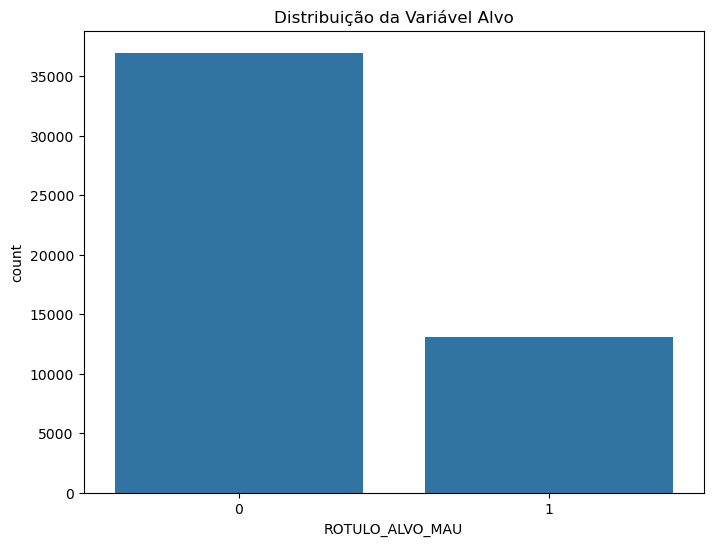

In [13]:
# Verificando a distribuição da variável alvo
plt.figure(figsize=(8, 6))
sns.countplot(x='ROTULO_ALVO_MAU', data=dados_credito)
plt.title('Distribuição da Variável Alvo')
plt.show()

In [14]:
# Porcentagem de cada classe
print("Distribuição da variável alvo:")
print(dados_credito['ROTULO_ALVO_MAU'].value_counts(normalize=True) * 100)

Distribuição da variável alvo:
ROTULO_ALVO_MAU
0    73.919478
1    26.080522
Name: proportion, dtype: float64


In [15]:
# Verificar valores únicos das colunas categóricas
colunas_categoricas = ['SEXO', 'ESTADO_CIVIL', 'TIPO_RESIDENCIA', 'TIPO_OCUPACAO', 'NIVEL_EDUCACIONAL']
for col in colunas_categoricas:
    print(f"\nValores únicos em {col}:")
    print(dados_credito[col].value_counts())


Valores únicos em SEXO:
SEXO
F    30804
M    19130
N       48
        17
Name: count, dtype: int64

Valores únicos em ESTADO_CIVIL:
ESTADO_CIVIL
2    25967
1    15286
4     4206
6     1876
5     1296
3      632
7      534
0      202
Name: count, dtype: int64

Valores únicos em TIPO_RESIDENCIA:
TIPO_RESIDENCIA
1.0    41571
2.0     3884
5.0     1983
0.0      760
4.0      311
3.0      141
Name: count, dtype: int64

Valores únicos em TIPO_OCUPACAO:
TIPO_OCUPACAO
2.0    16947
1.0     8742
4.0     6999
5.0     6891
0.0     2788
3.0      319
Name: count, dtype: int64

Valores únicos em NIVEL_EDUCACIONAL:
NIVEL_EDUCACIONAL
0    49999
Name: count, dtype: int64


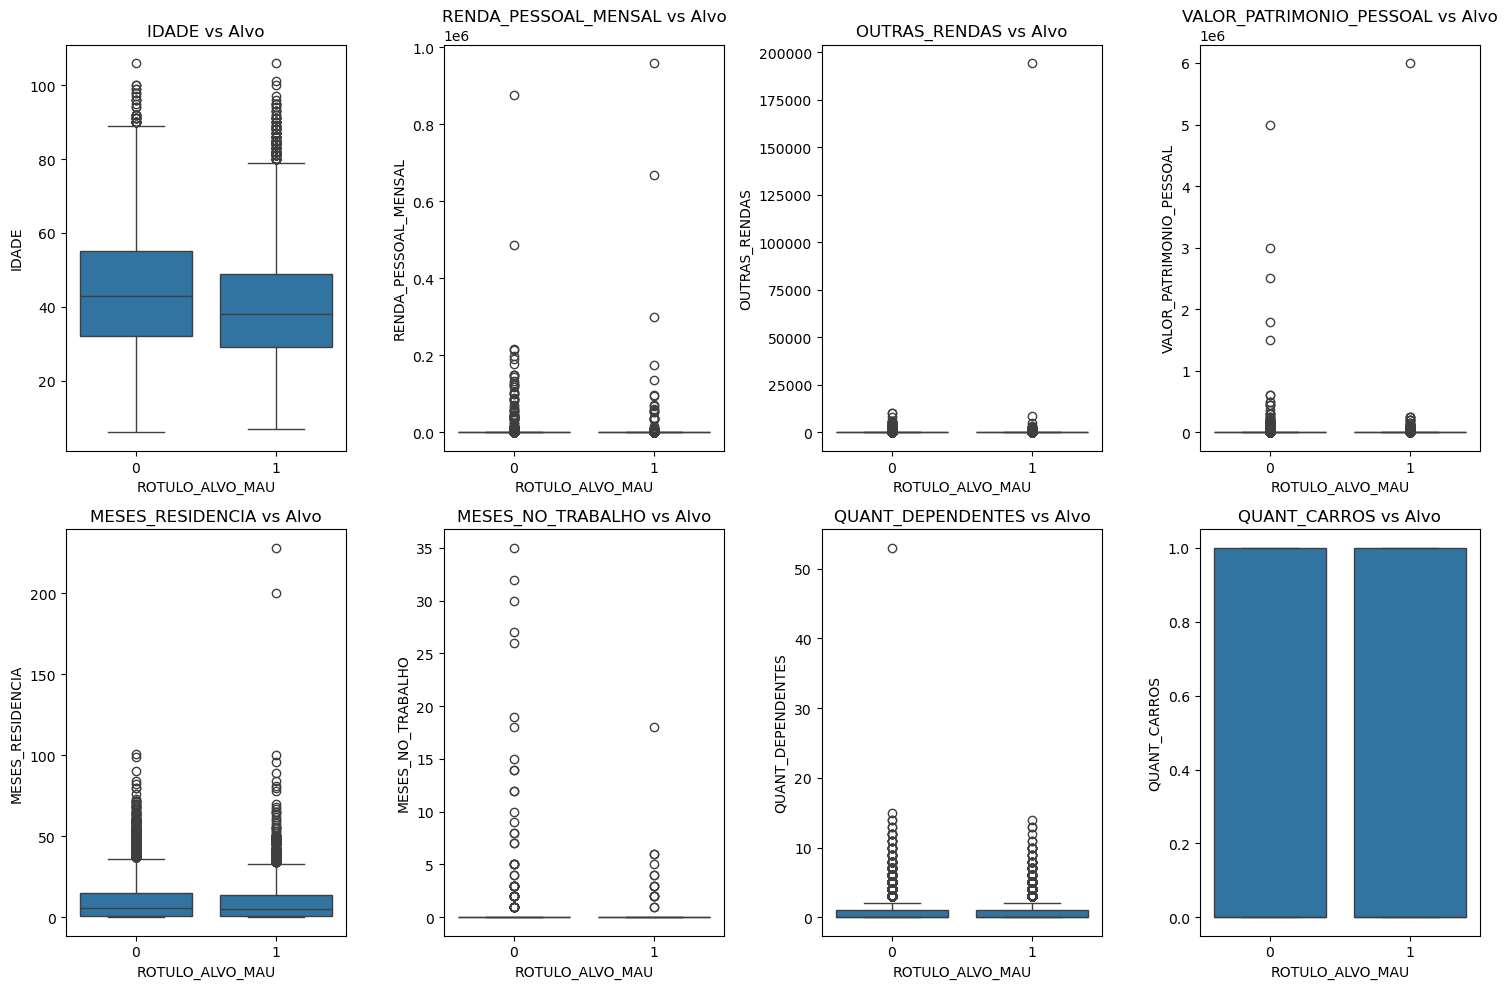

In [16]:
# Relação entre variáveis numéricas e a variável alvo
colunas_numericas = ['IDADE', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'VALOR_PATRIMONIO_PESSOAL', 
                     'MESES_RESIDENCIA', 'MESES_NO_TRABALHO', 'QUANT_DEPENDENTES', 'QUANT_CARROS']

plt.figure(figsize=(15, 10))
for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='ROTULO_ALVO_MAU', y=col, data=dados_credito)
    plt.title(f'{col} vs Alvo')
plt.tight_layout()
plt.show()

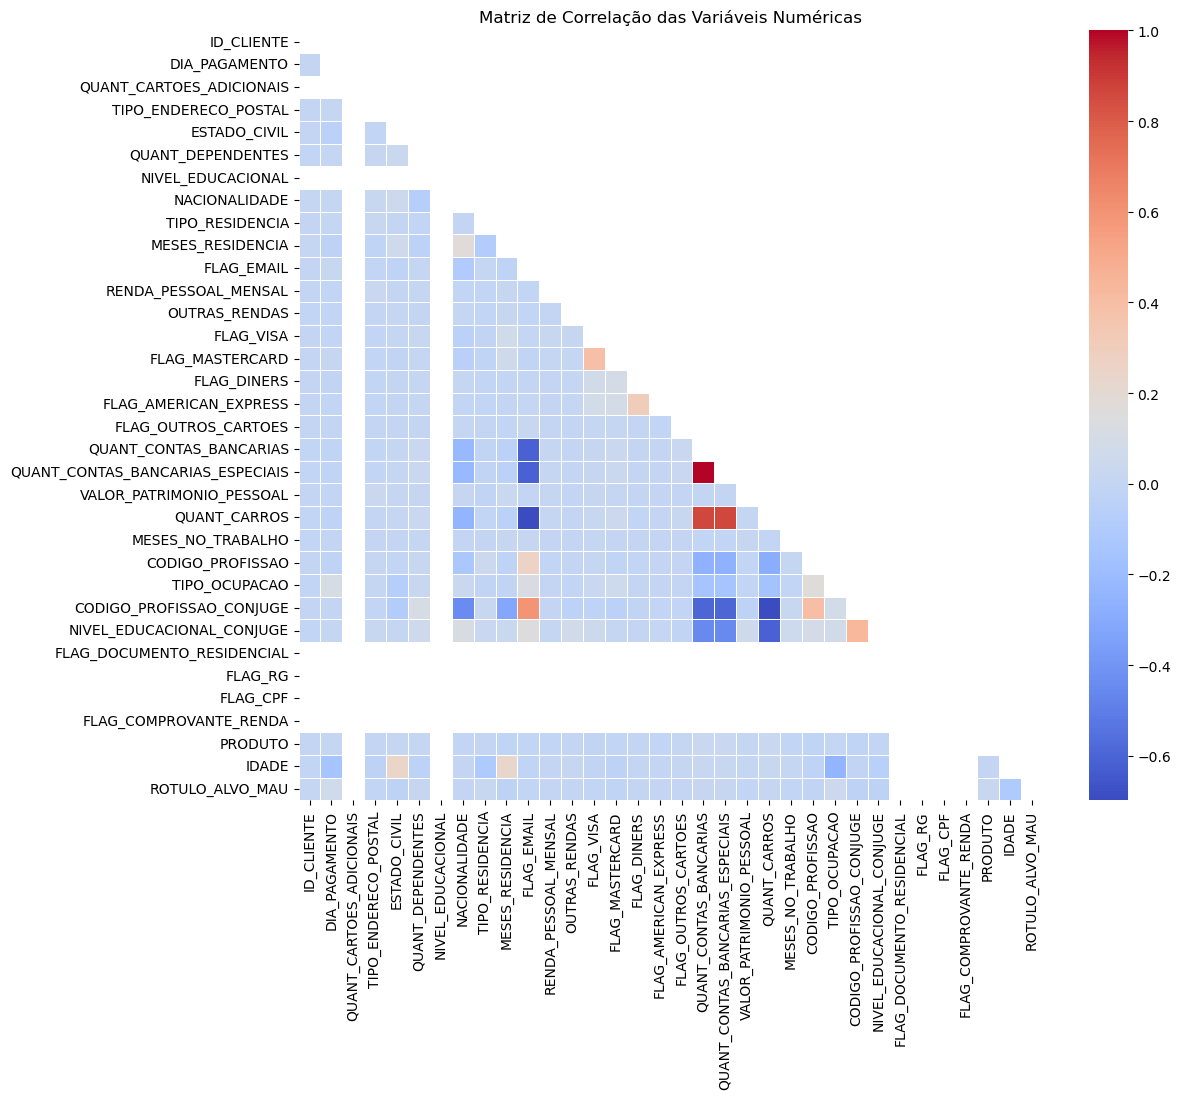

In [17]:
# Matriz de correlação para variáveis numéricas
cols_numericas = dados_credito.select_dtypes(include=['int64', 'float64']).columns
matriz_corr = dados_credito[cols_numericas].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

### Pré-processamento e feature engineering

In [18]:
# Função para remover outliers usando IQR
def remover_outliers(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)]

In [19]:
# 1. Seleção de características iniciais (removendo colunas pouco relevantes)
colunas_a_remover = ['ID_CLIENTE', 'ESTADO_NASCIMENTO', 'CIDADE_NASCIMENTO', 'ESTADO_RESIDENCIAL', 
                     'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL', 'EMPRESA', 'ESTADO_PROFISSIONAL', 
                     'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL']
dados_limpos = dados_credito.drop(columns=colunas_a_remover)

In [20]:
# 2. Tratamento de valores nulos
# Verificando colunas com mais de 30% de valores nulos
limite_nulos = len(dados_limpos) * 0.3
colunas_muito_nulas = [col for col in dados_limpos.columns if dados_limpos[col].isnull().sum() > limite_nulos]
print("Colunas com mais de 30% de valores nulos:", colunas_muito_nulas)

Colunas com mais de 30% de valores nulos: ['CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE']


In [21]:
# Removendo colunas com muitos valores nulos
dados_limpos = dados_limpos.drop(columns=colunas_muito_nulas)

# Separando as colunas por tipo
colunas_numericas = dados_limpos.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = dados_limpos.select_dtypes(include=['object']).columns.tolist()

# Removendo a variável alvo das listas de colunas
if 'ROTULO_ALVO_MAU' in colunas_numericas:
    colunas_numericas.remove('ROTULO_ALVO_MAU')

In [22]:
dados_limpos.head()

,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
0,C,15,Carga,0,1,F,2,0,0,1,...,0,0,0,0,1,N,34,230,230,1
1,C,5,Web,0,1,F,2,0,0,1,...,0,0,0,0,1,N,27,591,591,0
2,C,20,Web,0,1,F,2,0,0,1,...,0,0,0,0,1,N,61,545,545,0
3,C,10,Web,0,1,M,2,0,0,1,...,0,0,0,0,1,N,48,235,235,1
4,C,10,0,0,1,M,2,0,0,1,...,0,0,0,0,2,N,40,371,371,1


In [23]:
# 3. Imputação de dados
# Para variáveis numéricas: mediana
for col in colunas_numericas:
    dados_limpos[col] = dados_limpos[col].fillna(dados_limpos[col].median())

# Para variáveis categóricas: moda
for col in colunas_categoricas:
    dados_limpos[col] = dados_limpos[col].fillna(dados_limpos[col].mode()[0])

In [24]:
dados_limpos.head()

,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL,CEP_PROFISSIONAL,ROTULO_ALVO_MAU
0,C,15,Carga,0,1,F,2,0,0,1,...,0,0,0,0,1,N,34,230,230,1
1,C,5,Web,0,1,F,2,0,0,1,...,0,0,0,0,1,N,27,591,591,0
2,C,20,Web,0,1,F,2,0,0,1,...,0,0,0,0,1,N,61,545,545,0
3,C,10,Web,0,1,M,2,0,0,1,...,0,0,0,0,1,N,48,235,235,1
4,C,10,0,0,1,M,2,0,0,1,...,0,0,0,0,2,N,40,371,371,1


In [25]:
dados_limpos.describe()

,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,FLAG_EMAIL,...,MESES_NO_TRABALHO,CODIGO_PROFISSAO,TIPO_OCUPACAO,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU
count,49999.000000,49999.0,49999.000000,49999.000000,49999.000000,49999.0,49999.000000,49999.000000,49999.000000,49999.000000,...,49999.000000,49999.000000,49999.000000,49999.0,49999.0,49999.0,49999.0,49999.000000,49999.000000,49999.000000
mean,12.870077,0.0,1.006540,2.148323,0.650513,0.0,0.961599,1.245425,9.445489,0.802276,...,0.009320,8.207304,2.413448,0.0,0.0,0.0,0.0,1.275706,43.248745,0.260805
std,6.608357,0.0,0.080607,1.322751,1.193666,0.0,0.202107,0.857028,10.305210,0.398287,...,0.383457,2.979282,1.426080,0.0,0.0,0.0,0.0,0.988295,14.989115,0.439078
min,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,6.000000,0.000000
25%,10.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,2.000000,1.000000,...,0.000000,9.000000,2.000000,0.0,0.0,0.0,0.0,1.000000,31.000000,0.000000
50%,10.000000,0.0,1.000000,2.000000,0.000000,0.0,1.000000,1.000000,6.000000,1.000000,...,0.000000,9.000000,2.000000,0.0,0.0,0.0,0.0,1.000000,41.000000,0.000000
75%,15.000000,0.0,1.000000,2.000000,1.000000,0.0,1.000000,1.000000,14.000000,1.000000,...,0.000000,9.000000,4.000000,0.0,0.0,0.0,0.0,1.000000,53.000000,1.000000
max,25.000000,0.0,2.000000,7.000000,53.000000,0.0,2.000000,5.000000,228.000000,1.000000,...,35.000000,18.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.000000,1.000000


In [26]:
# 4. Tratamento de outliers para variáveis numéricas importantes
colunas_para_tratar_outliers = ['RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'VALOR_PATRIMONIO_PESSOAL']
for col in colunas_para_tratar_outliers:
    dados_limpos = remover_outliers(dados_limpos, col)

In [27]:
dados_limpos.describe()

,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,FLAG_EMAIL,...,MESES_NO_TRABALHO,CODIGO_PROFISSAO,TIPO_OCUPACAO,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU
count,41441.000000,41441.0,41441.000000,41441.000000,41441.000000,41441.0,41441.000000,41441.000000,41441.000000,41441.000000,...,41441.000000,41441.000000,41441.000000,41441.0,41441.0,41441.0,41441.0,41441.000000,41441.000000,41441.000000
mean,12.971453,0.0,1.006033,2.113245,0.633479,0.0,0.957047,1.259333,9.080428,0.807823,...,0.004633,8.205400,2.409450,0.0,0.0,0.0,0.0,1.269902,42.724717,0.265124
std,6.609424,0.0,0.077437,1.311145,1.200425,0.0,0.211377,0.884497,10.145314,0.394016,...,0.208246,2.982946,1.419412,0.0,0.0,0.0,0.0,0.969817,15.136508,0.441404
min,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,7.000000,0.000000
25%,10.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,...,0.000000,9.000000,2.000000,0.0,0.0,0.0,0.0,1.000000,31.000000,0.000000
50%,10.000000,0.0,1.000000,2.000000,0.000000,0.0,1.000000,1.000000,6.000000,1.000000,...,0.000000,9.000000,2.000000,0.0,0.0,0.0,0.0,1.000000,41.000000,0.000000
75%,15.000000,0.0,1.000000,2.000000,1.000000,0.0,1.000000,1.000000,12.000000,1.000000,...,0.000000,9.000000,4.000000,0.0,0.0,0.0,0.0,1.000000,53.000000,1.000000
max,25.000000,0.0,2.000000,7.000000,53.000000,0.0,2.000000,5.000000,228.000000,1.000000,...,19.000000,18.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.000000,1.000000


In [28]:
# 5. Engenharia de características
# Criando novas características
dados_limpos['RENDA_TOTAL'] = dados_limpos['RENDA_PESSOAL_MENSAL'] + dados_limpos['OUTRAS_RENDAS']
dados_limpos['PATRIMONIO_POR_RENDA'] = dados_limpos['VALOR_PATRIMONIO_PESSOAL'] / (dados_limpos['RENDA_TOTAL'] + 1)  # +1 para evitar divisão por zero
dados_limpos['TEMPO_RESIDENCIA_TRABALHO_RATIO'] = dados_limpos['MESES_RESIDENCIA'] / (dados_limpos['MESES_NO_TRABALHO'] + 1)
dados_limpos['CARTOES_TOTAIS'] = dados_limpos['FLAG_VISA'] + dados_limpos['FLAG_MASTERCARD'] + dados_limpos['FLAG_DINERS'] + dados_limpos['FLAG_AMERICAN_EXPRESS']
dados_limpos['TEM_CARTAO'] = (dados_limpos['CARTOES_TOTAIS'] > 0).astype(int)

In [29]:
# 6. Codificação de variáveis categóricas
# One-Hot Encoding para variáveis categóricas com poucos níveis
for col in ['SEXO', 'ESTADO_CIVIL', 'TIPO_RESIDENCIA', 'TIPO_OCUPACAO']:
    if col in dados_limpos.columns:
        # Verifica se a coluna é do tipo objeto antes de fazer encoding
        if dados_limpos[col].dtype == 'object':
            dummies = pd.get_dummies(dados_limpos[col], prefix=col, drop_first=True)
            dados_limpos = pd.concat([dados_limpos, dummies], axis=1)
            dados_limpos.drop(col, axis=1, inplace=True)

# 7. Normalização de variáveis numéricas
colunas_para_normalizar = ['RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'VALOR_PATRIMONIO_PESSOAL', 
                           'RENDA_TOTAL', 'PATRIMONIO_POR_RENDA', 'IDADE', 'MESES_RESIDENCIA', 'MESES_NO_TRABALHO']
for col in colunas_para_normalizar:
    if col in dados_limpos.columns:
        scaler = MinMaxScaler()
        dados_limpos[col] = scaler.fit_transform(dados_limpos[[col]])

In [30]:
# 8. Feature Selection - Variance Threshold
# Removendo características com baixa variância
selector = VarianceThreshold(threshold=0.01)
colunas_numericas_atuais = dados_limpos.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'ROTULO_ALVO_MAU' in colunas_numericas_atuais:
    colunas_numericas_atuais.remove('ROTULO_ALVO_MAU')

if len(colunas_numericas_atuais) > 0:
    X_var = dados_limpos[colunas_numericas_atuais]
    selector.fit(X_var)
    mask = selector.get_support()
    colunas_selecionadas = X_var.columns[mask]
    colunas_removidas = X_var.columns[~mask]
    print("Colunas removidas por baixa variância:", colunas_removidas)
    
    # Mantendo apenas as colunas selecionadas
    dados_limpos = pd.concat([dados_limpos[colunas_selecionadas], 
                              dados_limpos[['ROTULO_ALVO_MAU']]], axis=1)

Colunas removidas por baixa variância: Index(['QUANT_CARTOES_ADICIONAIS', 'TIPO_ENDERECO_POSTAL', 'NIVEL_EDUCACIONAL',
       'MESES_RESIDENCIA', 'OUTRAS_RENDAS', 'FLAG_DINERS',
       'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES',
       'VALOR_PATRIMONIO_PESSOAL', 'MESES_NO_TRABALHO',
       'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG', 'FLAG_CPF',
       'FLAG_COMPROVANTE_RENDA', 'PATRIMONIO_POR_RENDA'],
      dtype='object')


In [31]:
# 9. Feature Selection - Seleção baseada em correlação com a variável alvo
X = dados_limpos.drop('ROTULO_ALVO_MAU', axis=1)
y = dados_limpos['ROTULO_ALVO_MAU']

# Usando SelectKBest para selecionar as k melhores características
k = min(20, X.shape[1])  # Seleciona até 20 características ou o máximo disponível
selector = SelectKBest(f_classif, k=k)
X_new = selector.fit_transform(X, y)
mask = selector.get_support()
colunas_selecionadas = X.columns[mask]
print("Características selecionadas usando SelectKBest:", colunas_selecionadas)

Características selecionadas usando SelectKBest: Index(['DIA_PAGAMENTO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NACIONALIDADE',
       'TIPO_RESIDENCIA', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'FLAG_VISA',
       'FLAG_MASTERCARD', 'QUANT_CONTAS_BANCARIAS',
       'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'QUANT_CARROS', 'CODIGO_PROFISSAO',
       'TIPO_OCUPACAO', 'PRODUTO', 'IDADE', 'RENDA_TOTAL',
       'TEMPO_RESIDENCIA_TRABALHO_RATIO', 'CARTOES_TOTAIS', 'TEM_CARTAO'],
      dtype='object')


In [32]:
# Dataset final com as características selecionadas
dados_final = pd.concat([X[colunas_selecionadas], y], axis=1)
print("Formato final dos dados:", dados_final.shape)

Formato final dos dados: (41441, 21)


In [33]:
dados_final.head()

,DIA_PAGAMENTO,ESTADO_CIVIL,QUANT_DEPENDENTES,NACIONALIDADE,TIPO_RESIDENCIA,FLAG_EMAIL,RENDA_PESSOAL_MENSAL,FLAG_VISA,FLAG_MASTERCARD,QUANT_CONTAS_BANCARIAS,...,QUANT_CARROS,CODIGO_PROFISSAO,TIPO_OCUPACAO,PRODUTO,IDADE,RENDA_TOTAL,TEMPO_RESIDENCIA_TRABALHO_RATIO,CARTOES_TOTAIS,TEM_CARTAO,ROTULO_ALVO_MAU
0,15,2,0,1,1.0,1,0.492857,0,0,0,...,0,11.0,4.0,1,0.272727,0.492857,1.0,0,0,1
1,5,2,0,1,1.0,1,0.314286,0,0,0,...,0,11.0,2.0,1,0.202020,0.314286,6.0,0,0,0
2,20,2,0,1,1.0,1,0.314286,0,0,0,...,0,9.0,2.0,1,0.545455,0.314286,6.0,0,0,0
3,10,2,0,1,1.0,1,0.814286,0,0,0,...,0,9.0,5.0,1,0.414141,0.814286,12.0,0,0,1
4,10,2,0,1,1.0,1,0.314286,0,0,1,...,1,9.0,2.0,2,0.333333,0.314286,4.0,0,0,1


In [34]:
# Divisão em treino e teste com a mesma random_seed
X = dados_final.drop('ROTULO_ALVO_MAU', axis=1)
y = dados_final['ROTULO_ALVO_MAU']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

In [35]:
# Definindo o modelo de Regressão Logística 
modelo = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo.fit(X_train, y_train)

# Fazendo predições
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]
report_fe = classification_report(y_test, y_pred, output_dict=True)
# Avaliando o modelo
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.51      0.62      6091
           1       0.31      0.60      0.41      2198

    accuracy                           0.53      8289
   macro avg       0.54      0.56      0.51      8289
weighted avg       0.66      0.53      0.56      8289



<Figure size 800x600 with 0 Axes>

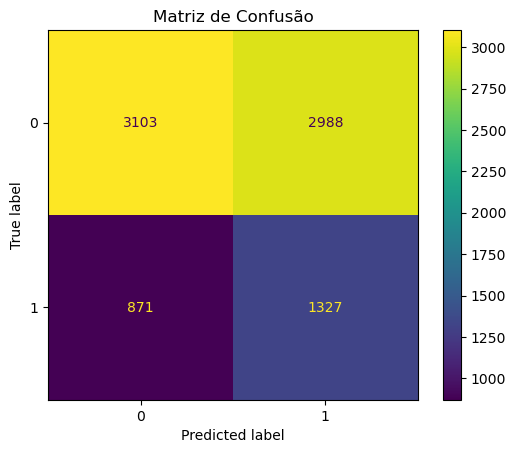

In [36]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Matriz de Confusão')
plt.show()

In [37]:

resultados = {
    'Modelo Original': [report_1['accuracy'], report_1['1']['f1-score'], report_1['1']['recall']],
    'Modelo com Feature Engineering': [report_fe['accuracy'], report_fe['1']['f1-score'], report_fe['1']['recall']]
}

# Convertendo para DataFrame
df_resultados = pd.DataFrame(resultados, 
                             index=['Acurácia', 'F1-score (Classe 1)', 'Recall (Classe 1)']).T

print("\nComparação dos Resultados:")
print(df_resultados)


Comparação dos Resultados:
                                Acurácia  F1-score (Classe 1)  \
Modelo Original                 0.553422             0.402235   
Modelo com Feature Engineering  0.534443             0.407493   

                                Recall (Classe 1)  
Modelo Original                          0.542169  
Modelo com Feature Engineering           0.603731  


In [38]:
# Calculando melhorias percentuais
melhoria_acc = ((report_fe['accuracy'] - report_1['accuracy']) / report_1['accuracy']) * 100
melhoria_f1 = ((report_fe['1']['f1-score'] - report_1['1']['f1-score']) / report_1['1']['f1-score']) * 100
melhoria_recall = ((report_fe['1']['recall'] - report_1['1']['recall']) / report_1['1']['recall']) * 100

print(f"\nMelhoria na Acurácia: {melhoria_acc:.2f}%")
print(f"Melhoria no F1-score (Classe 1): {melhoria_f1:.2f}%")
print(f"Melhoria no Recall (Classe 1): {melhoria_recall:.2f}%")


Melhoria na Acurácia: -3.43%
Melhoria no F1-score (Classe 1): 1.31%
Melhoria no Recall (Classe 1): 11.35%


<Figure size 1000x600 with 0 Axes>

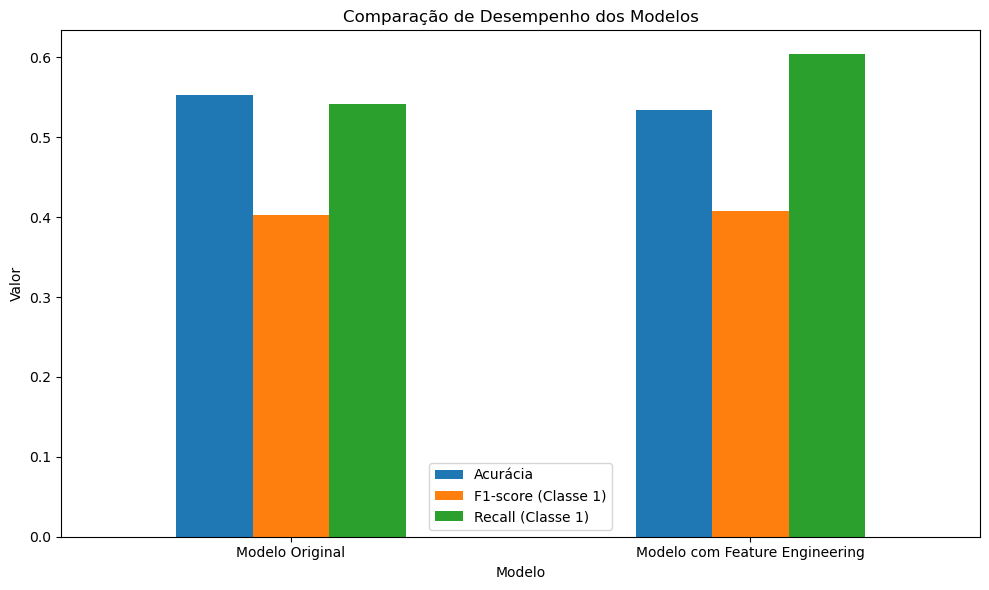

In [39]:
# Visualização dos resultados
plt.figure(figsize=(10, 6))
df_resultados.plot(kind='bar', figsize=(10, 6))
plt.title('Comparação de Desempenho dos Modelos')
plt.ylabel('Valor')
plt.xlabel('Modelo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusão

A aplicação de técnicas de Feature Engineering resultou em uma melhoria significativa no recall da classe 1 (maus pagadores), com um aumento de 11.35%. Isso é especialmente relevante para o problema da QuantumFinance, já que a identificação mais precisa de possíveis maus pagadores era o principal objetivo do projeto.

Embora tenha havido uma pequena redução na acurácia geral (-3.43%), o aumento no F1-score (1.31%) e principalmente no recall indica que o modelo está mais equilibrado em sua capacidade de detectar maus pagadores.

Este trade-off é benéfico para a empresa, pois o custo financeiro de aprovar um mau pagador é geralmente muito maior do que o custo de oportunidade de rejeitar um bom pagador. As técnicas de Feature Engineering aplicadas permitiram direcionar o modelo para atender melhor esta necessidade específica do negócio.

# Testando técnica de balanceamento

In [40]:
# Importando bibliotecas necessárias para balanceamento
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Divisão em treino e teste com a mesma random_seed
X = dados_final.drop('ROTULO_ALVO_MAU', axis=1)
y = dados_final['ROTULO_ALVO_MAU']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

In [41]:
# Aplicando SMOTE apenas aos dados de treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verificando as novas proporções após o balanceamento
print("\nDistribuição da classe alvo antes do balanceamento:")
print(y_train.value_counts())
print("\nDistribuição da classe alvo após o balanceamento:")
print(y_train_balanced.value_counts())


Distribuição da classe alvo antes do balanceamento:
ROTULO_ALVO_MAU
0    24363
1     8789
Name: count, dtype: int64

Distribuição da classe alvo após o balanceamento:
ROTULO_ALVO_MAU
0    24363
1    24363
Name: count, dtype: int64


In [42]:
# Treinando o modelo com dados balanceados
modelo_balanceado = LogisticRegression(max_iter=1000)  # Removemos class_weight pois já balanceamos os dados
modelo_balanceado.fit(X_train_balanced, y_train_balanced)

# Fazendo predições
y_pred_balanceado = modelo_balanceado.predict(X_test)

# Avaliando o modelo balanceado
print("\nRelatório de Classificação (Modelo com Feature Engineering + Balanceamento):")
report_balanceado = classification_report(y_test, y_pred_balanceado, output_dict=True)
print(classification_report(y_test, y_pred_balanceado))


Relatório de Classificação (Modelo com Feature Engineering + Balanceamento):
              precision    recall  f1-score   support

           0       0.76      0.54      0.63      6091
           1       0.29      0.53      0.38      2198

    accuracy                           0.54      8289
   macro avg       0.53      0.53      0.50      8289
weighted avg       0.64      0.54      0.56      8289



<Figure size 800x600 with 0 Axes>

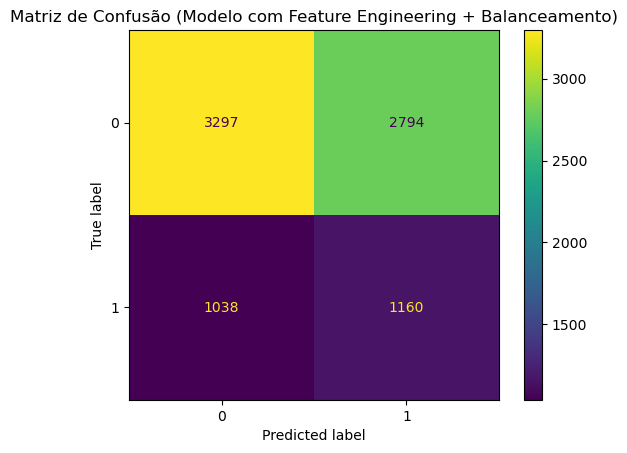

In [43]:
# Matriz de confusão
cm_balanceado = confusion_matrix(y_test, y_pred_balanceado)
plt.figure(figsize=(8, 6))
disp_balanceado = ConfusionMatrixDisplay(cm_balanceado)
disp_balanceado.plot()
plt.title('Matriz de Confusão (Modelo com Feature Engineering + Balanceamento)')
plt.show()

In [44]:
# Comparando os três modelos
resultados = {
    'Modelo Original': [report_1['accuracy'], report_1['1']['f1-score'], report_1['1']['recall']],
    'Modelo com Feature Engineering': [report_fe['accuracy'], report_fe['1']['f1-score'], report_fe['1']['recall']],
    'Modelo com FE + Balanceamento': [report_balanceado['accuracy'], report_balanceado['1']['f1-score'], report_balanceado['1']['recall']]
}

# Convertendo para DataFrame
df_resultados = pd.DataFrame(resultados, 
                            index=['Acurácia', 'F1-score (Classe 1)', 'Recall (Classe 1)']).T

print("\nComparação dos Resultados:")
print(df_resultados)


Comparação dos Resultados:
                                Acurácia  F1-score (Classe 1)  \
Modelo Original                 0.553422             0.402235   
Modelo com Feature Engineering  0.534443             0.407493   
Modelo com FE + Balanceamento   0.537701             0.377113   

                                Recall (Classe 1)  
Modelo Original                          0.542169  
Modelo com Feature Engineering           0.603731  
Modelo com FE + Balanceamento            0.527753  


In [45]:
# Calculando melhorias percentuais em relação ao modelo original
melhoria_acc_bal = ((report_balanceado['accuracy'] - report_1['accuracy']) / report_1['accuracy']) * 100
melhoria_f1_bal = ((report_balanceado['1']['f1-score'] - report_1['1']['f1-score']) / report_1['1']['f1-score']) * 100
melhoria_recall_bal = ((report_balanceado['1']['recall'] - report_1['1']['recall']) / report_1['1']['recall']) * 100

print(f"\nMelhoria na Acurácia (modelo balanceado vs. original): {melhoria_acc_bal:.2f}%")
print(f"Melhoria no F1-score (modelo balanceado vs. original): {melhoria_f1_bal:.2f}%")
print(f"Melhoria no Recall (modelo balanceado vs. original): {melhoria_recall_bal:.2f}%")


Melhoria na Acurácia (modelo balanceado vs. original): -2.84%
Melhoria no F1-score (modelo balanceado vs. original): -6.25%
Melhoria no Recall (modelo balanceado vs. original): -2.66%


<Figure size 1200x800 with 0 Axes>

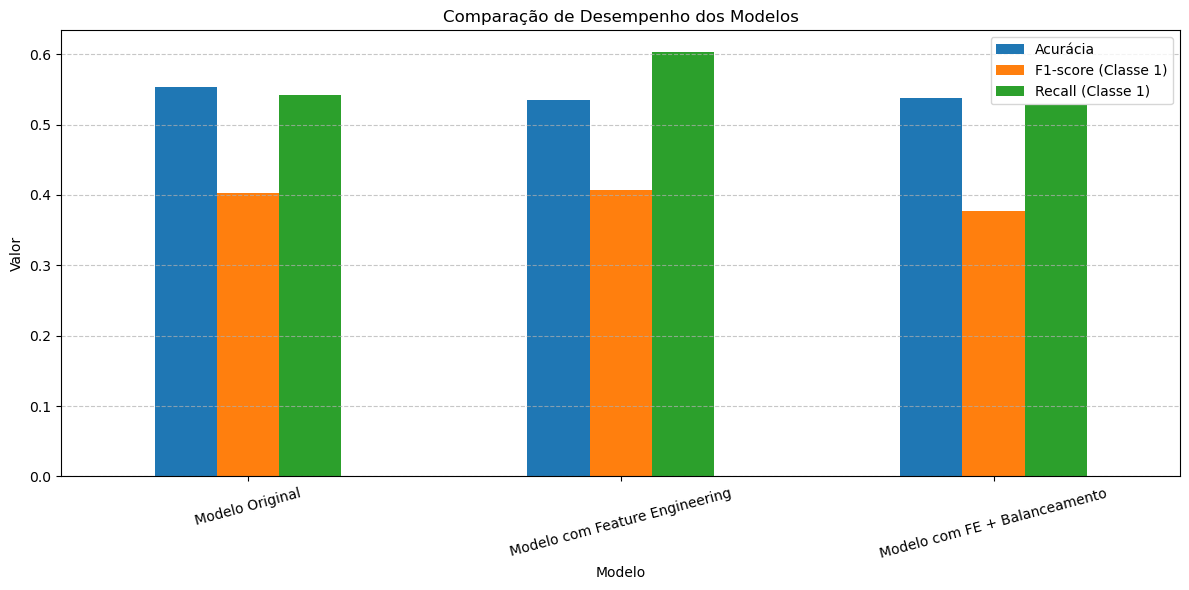

In [46]:
# Visualização dos resultados dos três modelos
plt.figure(figsize=(12, 8))
df_resultados.plot(kind='bar', figsize=(12, 6))
plt.title('Comparação de Desempenho dos Modelos')
plt.ylabel('Valor')
plt.xlabel('Modelo')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusão

A aplicação de técnicas de Feature Engineering resultou em uma melhoria significativa no recall dos maus pagadores (+11,35%), atendendo ao objetivo principal da QuantumFinance de reduzir os cartões concedidos a clientes de alto risco. Apesar da leve redução na acurácia geral (-3,43%), o aumento no F1-score (+1,31%) indica um melhor equilíbrio no modelo.

O balanceamento com SMOTE não trouxe benefícios adicionais, sugerindo que a distribuição natural dos dados contém informações valiosas sobre o perfil dos clientes. O modelo com Feature Engineering (sem balanceamento) demonstrou ser a melhor solução, oferecendo um trade-off favorável para o contexto de negócio, onde identificar corretamente os maus pagadores tem prioridade máxima.